# Score Centering Stabilizes Off-policy Reinforcement Learning

这篇论文是 Martin Marek 与 Max Ryabinin 的 arXiv 预印本《Score Centering Stabilizes Off-policy Reinforcement Learning》，2026-09-17 提交，类别 cs.LG，官方代码已开源。它讨论的“off-policy”不是传统探索意义上的 behavior/clinic policy 偏离，而是大模型 RL 中更工程化、也更致命的 <font color='red'>training-inference mismatch</font>, TIM：采样 rollout 的推理引擎 $q_θ$与计算梯度的训练引擎 $p_θ$不完全一致，例如量化、不同 kernel/代码库、浮点非结合性、异步陈旧、MoE 路由不一致等。
- 核心结论是：TIM 下崩溃的主因是 drift(漂移)，而 score centering 用一个加性修正项把它精确消掉。

## 一句话概括：
- 在大模型 RL 中，训练引擎与推理引擎之间的数值失配（TIM）之所以让训练崩溃，<font color='red'>本质是梯度里混入了一个会不断累积的 “drift（漂移）” 项</font>；
  - 作者推导出一个加性的 “score centering（分数中心化）” 修正项，通过抵消 drift 来稳定训练，且能与主流的重要性采样方法叠加使用。

##  问题：为什么 SFT 稳，LLM RL 却会因小数点级失配而崩？
- SFT 可以完全离线用另一个模型生成的数据训练，仍然稳定；
- 但在线 policy gradient 在 TIM 下会出现一个只在“教师会跟着学生更新”时才危险的机制。论文把每个 token 的期望更新分解为：

In [1]:
from IPython.display import Image

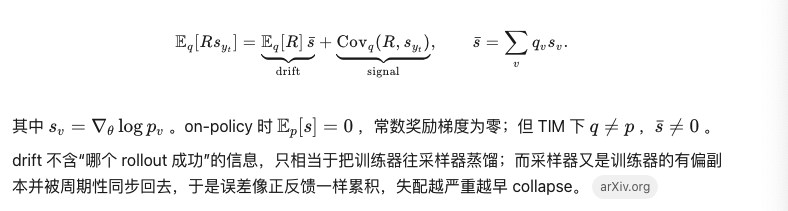

In [2]:
Image(filename='./Image/sc_01.png')

## 方法：score centering
做法非常直接：把每个 token score 减去<font color='red'>采样器期望 score</font>，


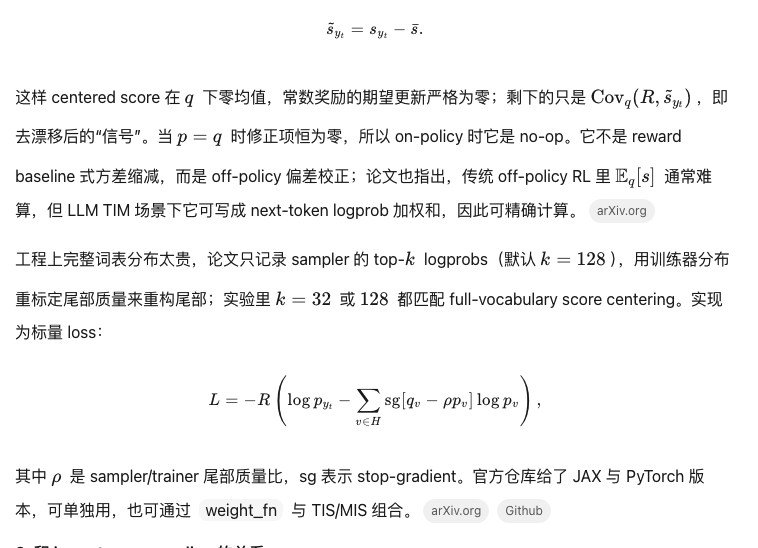

In [3]:
Image(filename='./Image/sc_02.png')

## 和 importance sampling 的关系
精确 IS 也能消 drift，但它是随机乘性修正：稀有 token 的 p/q  可能极大，实际系统几乎都 clip/mask，于是重新引入 bias。Score centering 是给定 prefix 的确定性加性修正，不依赖被采样 token，也没有超参数。两者正交：IS 先重加权分数，再对加权分数做 centering；当训练器在两次同步间移动很远、即严重 staleness 时，论文建议 SC + TIS/MIS，而不是单独 SC。

##  实验与结果
实验统一在 REINFORCE + group-centered rewards 的共享目标上比较各修正项，模型包括 Qwen3-0.6B/1.7B Countdown，以及 Qwen3-30B-A3B-Base 的 INTELLECT-2 math；失配来源分三类：合成权重噪声、严重量化、cron/staleness。总体规律是：轻度 TIM 下各方法差不多；TIM 越强，drift 累积越快，差异越明显。严重权重噪声下，只有 SC 单独或 SC+TIS/MIS 稳定；严重量化下 SC/TIS/MIS 最好；严重 staleness 下 SC 与 IS 组合最优，因为 SC 后协方差仍在 q  下而非 p  下测量，IS 可部分校正残余分布差异。

30B 结果最有说服力：FP8 sampler 下朴素 PG 也能到约 58%；KV cache 到 FP4 后 PG 约 200 步内崩、MIS 后期崩，而 SC 约 52%、TIS 约 51% 仍稳定；最严苛 INT8 权重/激活 + INT4 KV 下，SC 约 30%，TIS 约 12%，其它方法多低于 5%。这说明在强数值失配下，单纯消 drift 可以比带 clip 的 IS 更稳。

##  局限与实用判断
局限主要有两点：第一，SC 消掉 drift 后，剩余更新仍是在 q  下测 covariance，不是理想 on-policy 的 p ，所以严重 staleness 要组合 IS；第二，论文为在有限算力内拉开方法差距， headline 实验用了“故意加重”的短序列 TIM 作为长程温和失配的代理，外推到真实长训练时需要谨慎。

实操上我会这样总结：如果你只能做一件低成本事，开启 score centering 很划算——无超参数、加性、可与现有 TIS/MIS/PPO 系修正叠加；采样端只需额外记录 top-k  logprobs 和被采样 token logprob。若你的系统主要是数值/量化失配，SC 往往单独就够；若是异步 rollout、长上下文 agent、cron 同步很慢，则优先 SC+TIS/MIS。它不改变奖励设计，也不替代 clip/trust-region 类方法处理“策略真的移动很远”的情形，而是专门补上 TIM 带来的系统性漂移这块短板。

# 消除训练推理不一致：Score Centering 破解大模型强化学习漂移崩塌之谜

在大模型强化学习中，<font color='red'>训练与推理引擎间的细微数值差异（ TIM ）</font>极易诱发致命的训练崩塌。

最新 arXiv 突破论文《 Score Centering Stabilizes Off-policy RL 》首次**在数学上**揭开谜局： TIM 的根源是<font color='red'>采样器偏差</font>在,在线循环中形成了恶性自蒸馏“漂移项”


研究团队提出了极其优雅的<font color='red'>加法修正</font>—-—**分值中心化（ Score Centering ）**，仅用 5 行代码在每个前缀下**恒等消除漂移**，在极端量化与异步陈旧场景下**全面超越传统重要性采样**，为超大规模异策略强化学习筑牢了高韧性理论底座。


在以推理扩展（ Test-Time Compute ）与大规模强化学习（ RL ）为核心的后训练时代，强化学习正在吃掉越来越多的 GPU 算力。无论是以 PPO 、 GRPO 还是 REINFORCE 为底座的策略梯度算法，整个训练流水线都包含两个<font color='red'>看似对等</font>的核心步骤：
  -  采样器（ Inference/Sampler Engine ）：由 vLLM 、 TensorRT-LLM 或 SGLang 等**推理引擎**高并发生成候选探索轨迹（ Rollouts ）；
  -  训练器（ Training Engine ）：由 Megatron 、 FSDP 或 DeepSpeed 等并行框架对带有环境奖励的轨迹执行前向计算与梯度反向传播。
 
<font color='red'>在教科书的数学理论中</font>，采样器与训练器代表着完全相同的策略模型参数，<font color='blue'>两者的前向概率输出理应严丝合缝、完全一致</font>

<font color='blue'>然而在真实的工业级万卡集群中</font>，“训练与推理完全一致”<font color='red'>只是一个美丽的幻觉。</font>

由于推理端广泛采用的**低比特量化**（ FP8 、 FP4 、 INT8 ）、 FlashAttention 等 GPU 算子在不同批次大小下浮点加法的非结合性（ Non-associativity ）
  - 训练与推理两套独立代码库的微小实现差异，以及为了打满 GPU 利用率而引入的异步流水线与陈旧性（ Staleness ）——<font color='blue'>训练器与采样器之间必然存在难以消除的微小数值偏差</font>，业界称之为 “训练-推理不一致（ Training-Inference Mismatch, TIM ）”

- **这种细微到小数点后几位的数值偏差，在监督微调（ SFT ）中几乎可以忽略不计**；
- <font color='red'>但在强化学习中，它却化身为致命的毒药</font>——不仅导致收敛变慢，更频繁在数百步训练后诱发灾难性的“奖励雪崩与模型坍塌”。



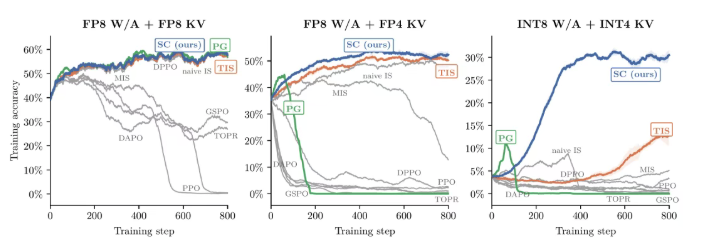

In [4]:
Image(filename='./Image/vx_01.png')

为什么强化学习对 TIM 如此脆弱？<font color='red'>工业界过去依赖的“截断重要性采样（ Importance Sampling, IS ）”为何频频失效？</font>

近日，来自牛津大学与前沿研究机构的学者（ Martin Marek, Max Ryabinin ）在 arXiv 发表了重磅理论与实证长文——《 Score Centering Stabilizes Off-policy Reinforcement Learning 》（ arXiv:2609.20807v1 ）。该研究首次在数学上证明：TIM 诱发训练崩塌的本质，是策略梯度中悄然滋生了一个纯粹<font color='red'>由偏差累积形成的“漂移项（ Drift ）</font>”，它在,在线循环中强迫模型向其带噪的自身副本进行恶性自蒸馏！

基于这一重大发现，作者提出了一种极其震撼且优雅的全新修正算法——<font color='red'>分值中心化（ Score Centering ）</font>。只需仅仅 5 行代码，即可在每个前缀下恒等消除漂移，在跨越 0.6B 到 30B MoE 的极端量化与异步陈旧性实验中，彻底破解了强化学习的稳定性死穴。

## 01 / 现象之谜：为什么 SFT 坚如磐石，而 RL 屡遭崩塌？

要理解强化学习为何对 TIM 如此敏感，<font color='red'>首先要对比它与监督微调（ SFT ）的本质差异</font>。

在日常开发中，我们经常使用另一个完全不同的开源模型（甚至人类标注者）生成的数据直接对模型进行 SFT 蒸馏，训练过程始终平稳收敛。
- 换言之，SFT 面对哪怕高达 100% 的“模型不一致”，也绝不会发生数学层面的崩溃。

更耐人寻味的是，<font color='red'>在二元奖励（+1/0 ）且不更新采样器的离线设定下，策略梯度算法在数学上完全等价于 SFT </font>。那么，<font color='blue'>究竟是什么关键机制让强化学习在存在细微 TIM 时走向失稳？</font>

研究团队通过精心设计的对比消融实验（如下图），揭开了这一关键谜底：

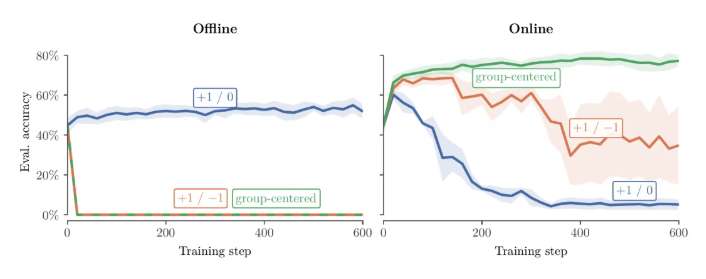

In [5]:
Image(filename='./Image/vx_02.png')

实验得出了一个完全反直觉的颠覆性结论：
-  离线微调（ Offline ）：在离线状态下，全正向奖励（+1/0 ）最稳定，**而负向惩罚（ 0/-1 ）由于对数概率下界无约束极易导致数值发散；**
-  在线强化学习（ Online under TIM ）：在存在训练--推理偏差的在线循环中，<font color='red'>全正向奖励（+1/0 ）反而最不稳定、崩塌得最早！</font> 相反，混合了正负优势的群组中心化奖励（如 GRPO 的 Group Centering ）反而表现得更为平稳。
 
这一现象直击要害：在线强化学习的不稳定，并非源于强化学习算法本身，<font color='red'>而是源于“在线更新（ Online Loop ）”与“正向奖励反馈”两者的致命交织！</font>

## 02 / 数学破译： TIM 诱发的“漂移项”恶性自蒸馏

为了从数学底层查明原因，研究团队对存在 TIM 时的策略梯度更新展开了因式分解。

在理论设定中，假设环境给出一个恒定的 +1 奖励。由于所有轨迹的奖励完全相同，环境中没有任何差异化的信息输入，在策略一致时期望梯度应当严格等于零（ abla_   heta \sum_v p_v =  abla_   heta 1 = 0 ），模型不应发生任何学习漂移。

然而，在存在 TIM 时，轨迹由采样器 q 生成，而梯度由训练器 p 计算。研究团队利用协方差恒等式，**将任意前缀处的期望策略梯度更新精确解构为两项之和**：

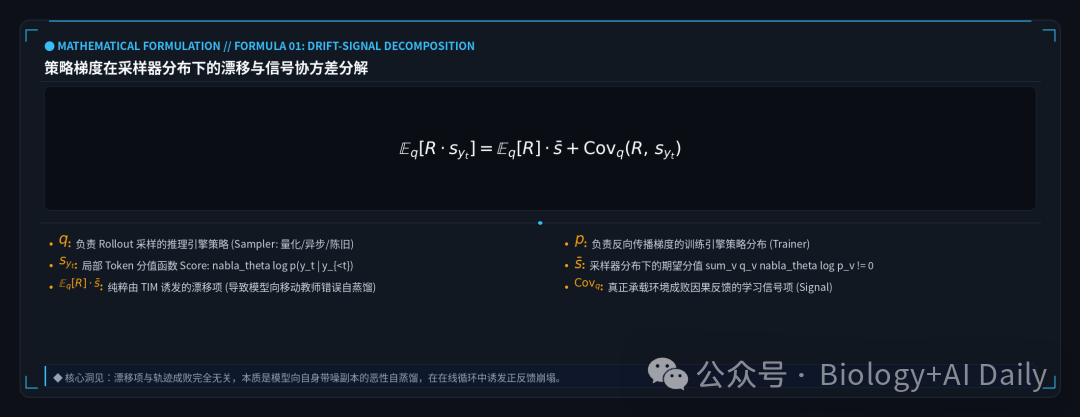

In [12]:
Image(filename='./Image/vx_03.png')

该公式揭示了大模型强化学习失稳的终极真相：

1. 真实学习信号（ Signal: $\mathrm{Cov}_q(R, s_{y_t}$)）：<font color='red'>只有协方差项能够感知不同 Token 与环境奖励之间的因果关联，这才是强化学习真正赖以提升能力的动力来源</font>

2. 纯粹人造副产物——漂移项（ Drift: $\mathbb{E}_q[R] \cdot \bar{s}$）：

  - 与成败毫无关系：漂移项仅仅取决于平均奖励 $\mathbb{E}_q[R] $和采样器下的期望分值 $\bar{s} = \sum_v q_v  \nabla \log p_v$，它完全不关心某一条具体的轨迹究竟是对是错；
  
  - 恶性正反馈蒸馏：从优化角度来看，$\bar{s}$ 恰恰是“以采样器 q 为教师对训练器 p 进行交叉熵监督微调”的负梯度！
  
  - 滚雪球式崩塌：如果教师是固定的，蒸馏并不会崩溃；但在这里，采样器 q 是训练器自身的一个带噪副本（如量化误差或陈旧权重）。在每一步更新中，漂移项都在强迫训练器向这个带噪的采样器看齐；更新后的权重又被同步回采样器，导致误差像滚雪球一样不断放大，最终在正反馈闭环中走向不可逆的策略崩溃！
    
  这就彻底解释了为什么在图 2 中全正奖励崩塌最快：因为平均奖励 $\mathbb{E}_q[R] $越大，这个错误的自蒸馏漂移项就被放得越大！
  
### 那么， GRPO 的群组中心化能解决漂移吗？答案是：不能！
  - 许多工程师直觉认为， GRPO 将一个 Prompt 下采样的多条轨迹进行均值归一化，奖励均值已经是 0 了，漂移难道不存在吗？
  - 作者指出：GRPO 只是让整个 Prompt 级别的全局优势和为零，<font color='red'>但在具体的 Token 前缀处，期望优势依然非零！</font> 
    - 一个通往正确解的前缀具有正期望优势，
    - 一个出现笔误的前缀具有负期望优势。
    - 因此，在真正携带学习信号的所有关键前缀上，漂移项依然根深蒂固，持续侵蚀着训练过程。
  
## 03 / 优雅之解：分值中心化（ Score Centering ）

既然漂移项的根源在于采样器下的期望分值 $bar{s}$  e 0，解决它的最直接、最纯粹的方法是什么？

- <font color='red'>让期望分值在每个前缀下恒等于零！</font>

研究团队据此提出了颠覆性的 <font color='red'>分值中心化（ Score Centering ）</font>：在计算梯度时，直接从原始分值中减去其在采样器下的期望值：

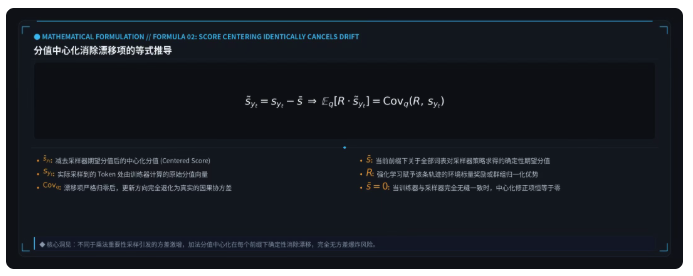

In [7]:
Image(filename='./Image/vx_04.png')

这一修正带来了三大震撼特质：

1. 恒等消除漂移：因为期望分值被严格拉平至零，漂移项 $\mathbb{E}_q[R] \cdot \mathbb{E}_q[    ilde{s}] $严格消失，更新方向完全退化为真实的因果协方差 $\mathrm{Cov}_q(R, s)$；

2. 零方差放大：传统的重要性采样（ IS ）是通过乘上比率 p(y)/q(y) 来抵消偏差，<font color='red'>但在罕见 Token 处这一比率会发散至极大值，导致梯度方差爆炸</font>，迫使人们不得不引入硬截断（ Clip/Mask ），而截断又会把漂移重新带回来；相反，<font color='blue'>分值中心化是加法修正，且修正量在当前前缀下是完全确定的常数向量，绝不会产生任何极端权重与方差放大！</font>

3. 一致时自动退化：在没有 TIM 的理想情况下（p = q），$bar{s}$ 本身就恒等于 0 ，修正项自然为零，不影响任何正常训练。

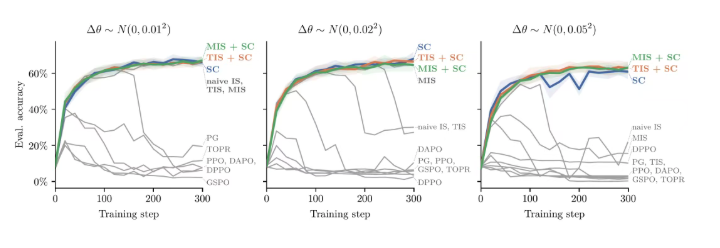

In [8]:
Image(filename='./Image/vx_05.png')

如图 3 所示，在人为注入权重的扰动实验中，传统基线（如 DPPO 、 TIS ）随着训练步数推移，漂移持续累积并在几十步到上百步内相继发生雪崩；
- 唯独分值中心化（ Score Centering ）能够全程保持极度平稳的奖励曲线，从根源上斩断了漂移的死循环！


## 04 / 极简落地：仅需 5 行代码与 Top-k 尾部补偿

在工程落地层面，如何在庞大的全词表（如 15 万词表）上计算每个前缀处的期望分值 $\bar{s}$？如果每个 Token 都记录全词表概率，网络通信与显存开销将不可接受。

论文给出了一种极其聪明的 Top-k 尾部质量解析估计法：
  - 推理引擎在生成时，仅需记录最高概率的 k 个候选词（如 k=128 甚至 k=32）的对数概率；对于剩下数以万计的长尾低频词，利用训练器的尾部概率进行质量缩放补偿，将其等价推导为一个单标量损失函数：
  
  

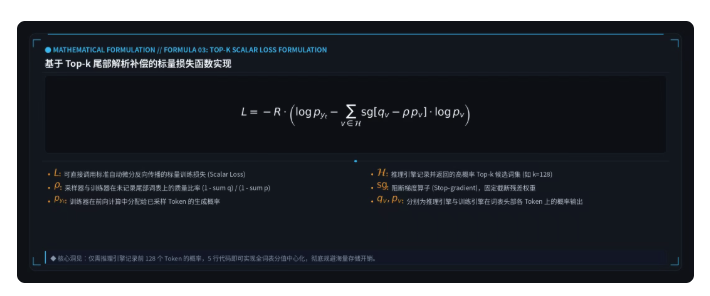

In [9]:
Image(filename='./Image/vx_06.png')

这一公式在工程实现上精炼到了极致，在 PyTorch 或 JAX 中只需短短 5 行核心代码：

In [ ]:
defscore_centering_loss(train_logp,samp_logp,topk_ids,sampled_token,advantage):
    train_head=train_logp[topk_ids]
    rho=(1.0-samp_logp.exp().sum())/(1.0-train_head.exp().sum())
    residual=samp_logp.exp()-rho*train_head.exp()
    logp_corr=(residual.detach()*train_head).sum()
    return -advantage*(train_logp[sampled_token]-logp_corr)

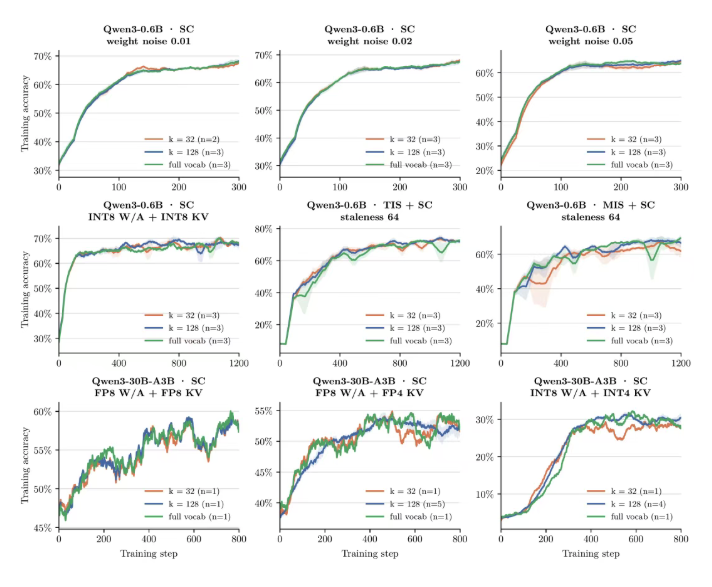

In [10]:
Image(filename='./Image/vx_07.png')

消融实验（图 5 ）表明：<font color='red'>k=128 乃至 k=32 的性能曲线与全词表完全重合！</font> 开发者几乎无需对推理引擎做出大刀阔斧的改动，即可享受到近乎零开销的稳定性增益。


## 05 / 正交复合：双剑合璧抵御极端异步陈旧性

既然分值中心化如此有效，**它是否能够与传统的重要性采样（ IS ）并存？**

<font color='red'>答案是：它们具有完美的正交复合能力！</font>

在分布式大模型强化学习（尤其是智能体编码任务）中，单次任务执行可能耗费数小时，推理引擎往往在几十甚至上百步之后才能同步一次最新权重，<font color='red'>产生剧烈的策略陈旧性（ Staleness ）</font>。

在这种极端场景下：
  -  截断重要性采样（ TIS/MIS ） 负责校正大步长带来的宏观分布漂移；
  -  分值中心化（ Score Centering ） <font color='red'>则负责定点清除截断操作后残留下来的内在漂移项！</font>
  
两者正交复合的目标函数如下：

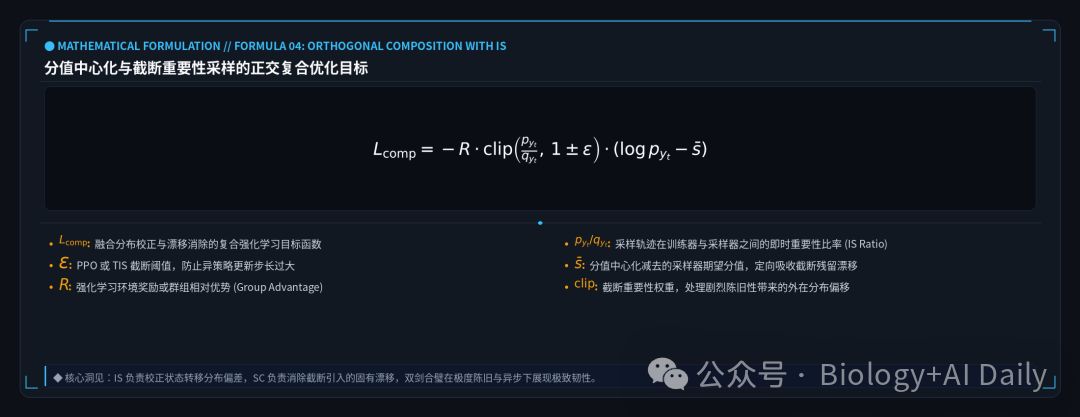

In [13]:
Image(filename='./Image/vx_08.png')

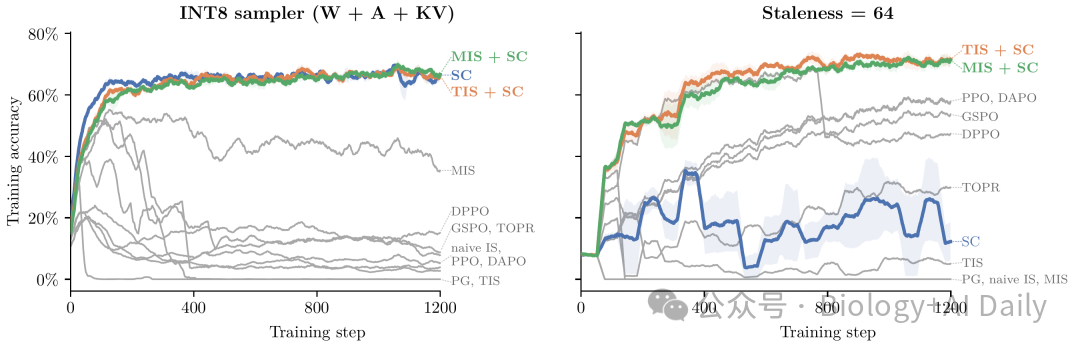

In [14]:
Image(filename='./Image/vx_09.png')

实测数据（图 4 ）展现了极具启发性的规律：
  - <font color='blue'> 在纯量化噪声下，单独使用 Score Centering 即已达到最佳性能</font>
  -  而在极其严苛的陈旧性测试中（采样器每隔整整 64 步才更新一次），Score Centering 与 TIS / MIS 的复合体（ TIS + SC / MIS + SC ）展现出了无与伦比的压制力，大幅甩开所有单一重要性采样基线！
  
## 06 / 规模化洗礼： 0.6B 到 30B MoE 的全景实测

为了彻底检验算法在大参数量模型与复杂架构下的扩展性，研究团队在 Qwen3-30B-A3B-Base （具有混合专家 MoE 架构） 以及 INTELLECT-2 高难度数学数据集上展开了终极大考：

实验覆盖了三级递进的严苛量化环境：
1. FP8 量化采样：所有方法表现稳定，模型准确率平稳提升至约 58%；

2. FP8 权重 + FP4 KV Cache 极限量化：
  - 未经修正的策略梯度在 200 步内彻底雪崩；
  - MIS 在训练后期发生恶性跳水；
  - 而 Score Centering 与 TIS 顶住了压力，准确率始终坚挺在 52% 的高位；

3. INT8 权重 + INT4 KV Cache 超极限环境：传统基线遭遇全面团灭（准确率均被压制在 5% 以下），而 Score Centering 独自突破重围，斩获 30% 的准确率（相比次优方法高出一倍以上）！
 
值得注意的是，在 MoE 架构中，量化甚至会导致训练器与采样器在专家路由（ Router Indices ）的选择上产生分歧。即使在如此严苛的扰动下， Score Centering 依然展现出了惊人的鲁棒性。

## 结语：给万卡强化学习装上“安全气囊”

大模型强化学习正以前所未有的速度重构通用人工智能的进化路径。然而，算力集群规模的膨胀与推理加速技术的推陈出新，<font color='red'>不可避免地让“训练-推理不一致（ TIM ）”成为了悬在每一位架构师头顶的达摩克利斯之剑。</font>

牛津团队这项研究所贡献的，不仅是一个在数学上无懈可击的优雅推导，更是一套极低接入成本、零显存负担、且在 30B 工业级模型上得到扎实验证的工程解法。

从破译“漂移项”的恶性自蒸馏本质，到用 5 行代码实现“分值中心化”的精准切除， Score Centering 为异策略强化学习由实验室玩具走向大规模工业化稳定生产，铺就了一块不可或缺的坚固基石。